# House Price Prediction

**Internship Project - Week 1**

**Name:** Pranay Agarwal

**Objective:** Build a regression model that predicts house prices based on property features such as size, number of rooms, location, and age - and identify which features most strongly influence price.

**Dataset:** [Housing Prices Dataset (Kaggle)](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

---

## Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Create charts directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Task 1 - Data Loading & Exploration
---

### 1.1 Load the CSV file using Pandas

In [2]:
# Load the dataset
df = pd.read_csv('Housing.csv')
print(f'Dataset loaded successfully! Shape: {df.shape}')

Dataset loaded successfully! Shape: (545, 13)


### 1.2 Display the first 10 rows

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,10600000,6750,4,3,1,yes,no,yes,no,no,1,no,semi-furnished
1,15700000,15150,6,4,2,no,no,no,no,no,0,yes,semi-furnished
2,10500000,6950,4,3,2,yes,no,no,no,no,0,no,unfurnished
3,10700000,5200,4,2,2,yes,no,no,no,yes,3,no,furnished
4,12300000,11050,4,3,1,yes,no,no,no,yes,3,no,semi-furnished
5,9800000,2650,3,3,2,yes,no,no,no,yes,1,no,furnished
6,8100000,6750,4,1,3,yes,no,no,no,no,0,no,unfurnished
7,9300000,7700,4,3,1,no,no,no,no,no,0,no,semi-furnished
8,11500000,12350,5,1,1,yes,no,yes,no,yes,1,yes,unfurnished
9,9600000,6000,2,2,1,yes,yes,no,no,no,2,no,semi-furnished


### 1.3 Check how many rows and columns are there

In [4]:
print(f'Number of Rows    : {df.shape[0]}')
print(f'Number of Columns : {df.shape[1]}')
print(f'\nColumn Names:\n{list(df.columns)}')

Number of Rows    : 545
Number of Columns : 13

Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
# Detailed info about each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Statistical summary of numerical columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,1.080367e+07,9186.697248,3.601835,1.990826,1.974312,1.001835
std,2.241222e+06,4078.297577,1.007872,0.887986,0.903059,0.910517
min,4.900000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,9.300000e+06,6100.000000,3.000000,1.000000,1.000000,0.000000
50%,1.070000e+07,9200.000000,4.000000,2.000000,2.000000,1.000000
75%,1.230000e+07,12700.000000,4.000000,3.000000,3.000000,2.000000
max,1.650000e+07,16100.000000,6.000000,4.000000,4.000000,3.000000


### 1.4 Identify the target and feature columns

In [7]:
target_column = 'price'
feature_columns = [col for col in df.columns if col != target_column]

print(f'Target Column  : {target_column}')
print(f'Feature Columns: {feature_columns}')
print(f'\nTotal Features: {len(feature_columns)}')

Target Column  : price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Total Features: 12


In [8]:
# Identify numerical vs categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical Columns  ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical Columns ({len(categorical_cols)}): {categorical_cols}')

Numerical Columns  (6): ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical Columns (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [9]:
# Check unique values in categorical columns
for col in categorical_cols:
    print(f'\n{col}: {df[col].unique()} (count: {df[col].nunique()})')


mainroad: ['yes' 'no'] (count: 2)

guestroom: ['no' 'yes'] (count: 2)

basement: ['yes' 'no'] (count: 2)

hotwaterheating: ['no' 'yes'] (count: 2)

airconditioning: ['no' 'yes'] (count: 2)

prefarea: ['no' 'yes'] (count: 2)

furnishingstatus: ['semi-furnished' 'unfurnished' 'furnished'] (count: 3)


### 1.5 Check for missing values in each column

In [10]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
})

print('Missing Values Summary:')
print('=' * 40)
print(missing_df)
print(f'\nTotal missing values in dataset: {df.isnull().sum().sum()}')

Missing Values Summary:
                  Missing Values  Percentage (%)
price                          0             0.0
area                           0             0.0
bedrooms                       0             0.0
bathrooms                      0             0.0
stories                        0             0.0
mainroad                       0             0.0
guestroom                      0             0.0
basement                       0             0.0
hotwaterheating                0             0.0
airconditioning                0             0.0
parking                        0             0.0
prefarea                       0             0.0
furnishingstatus               0             0.0

Total missing values in dataset: 0


---
## Task 2 - Data Cleaning
---

### 2.1 Handle missing values

In [11]:
# Check for missing values
total_missing = df.isnull().sum().sum()

if total_missing == 0:
    print('No missing values found in the dataset!')
else:
    print(f'Found {total_missing} missing values. Handling them now...')
    
    # Fill numerical columns with median
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'  - Filled {col} with median: {median_val}')
    
    # Fill categorical columns with mode
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f'  - Filled {col} with mode: {mode_val}')
    
    print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

No missing values found in the dataset!


### 2.2 Remove duplicate rows

In [12]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Removed {duplicates} duplicate rows.')
    print(f'New shape: {df.shape}')
else:
    print('No duplicate rows to remove.')

Duplicate rows found: 0
No duplicate rows to remove.


### 2.3 Convert categorical columns to numeric (One-Hot Encoding)

In [13]:
print(f'Shape BEFORE encoding: {df.shape}')
print(f'Categorical columns to encode: {categorical_cols}\n')

# Binary yes/no columns - map to 1/0 directly
binary_cols = [col for col in categorical_cols if set(df[col].unique()) == {'yes', 'no'}]
multi_cols = [col for col in categorical_cols if col not in binary_cols]

print(f'Binary (yes/no) columns: {binary_cols}')
print(f'Multi-category columns : {multi_cols}')

# Convert binary columns: yes -> 1, no -> 0
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
    print(f'  Mapped {col}: yes=1, no=0')

# One-hot encode multi-category columns (if any)
if multi_cols:
    df = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)
    print(f'  One-hot encoded: {multi_cols}')

print(f'\nShape AFTER encoding: {df.shape}')
df.head()

Shape BEFORE encoding: (545, 13)
Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']



Binary (yes/no) columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
Multi-category columns : ['furnishingstatus']
  Mapped mainroad: yes=1, no=0
  Mapped guestroom: yes=1, no=0
  Mapped basement: yes=1, no=0
  Mapped hotwaterheating: yes=1, no=0
  Mapped airconditioning: yes=1, no=0
  Mapped prefarea: yes=1, no=0
  One-hot encoded: ['furnishingstatus']

Shape AFTER encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,10600000,6750,4,3,1,1,0,1,0,0,1,0,1,0
1,15700000,15150,6,4,2,0,0,0,0,0,0,1,1,0
2,10500000,6950,4,3,2,1,0,0,0,0,0,0,0,1
3,10700000,5200,4,2,2,1,0,0,0,1,3,0,0,0
4,12300000,11050,4,3,1,1,0,0,0,1,3,0,1,0


### 2.4 Keep only meaningful columns

In [14]:
# All columns are meaningful for prediction in this dataset
# Let's verify by checking correlation with price
correlations = df.corr(numeric_only=True)['price'].drop('price').sort_values(ascending=False)
print('Correlation of each feature with Price:')
print('=' * 45)
for feature, corr in correlations.items():
    sign = '+' if corr > 0 else '-'
    print(f'{feature:25s} {sign}{abs(corr):.4f}')

print(f'\nKeeping all {len(df.columns)} columns - all features are relevant for prediction.')

Correlation of each feature with Price:
area                      +0.6939
bathrooms                 +0.5322
stories                   +0.3145
bedrooms                  +0.2353
prefarea                  +0.1884
mainroad                  +0.1357
airconditioning           +0.1323
parking                   +0.1101
basement                  +0.0371
hotwaterheating           +0.0215
guestroom                 -0.0090
furnishingstatus_semi-furnished -0.0214
furnishingstatus_unfurnished -0.0893

Keeping all 14 columns - all features are relevant for prediction.


In [15]:
# Final cleaned dataset overview
print('\nFinal Cleaned Dataset Summary:')
print(f'   Rows   : {df.shape[0]}')
print(f'   Columns: {df.shape[1]}')
print(f'   Missing: {df.isnull().sum().sum()}')
print(f'   Dtypes : {dict(df.dtypes.value_counts())}')
df.head()


Final Cleaned Dataset Summary:
   Rows   : 545
   Columns: 14
   Missing: 0
   Dtypes : {dtype('int64'): np.int64(14)}


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,10600000,6750,4,3,1,1,0,1,0,0,1,0,1,0
1,15700000,15150,6,4,2,0,0,0,0,0,0,1,1,0
2,10500000,6950,4,3,2,1,0,0,0,0,0,0,0,1
3,10700000,5200,4,2,2,1,0,0,0,1,3,0,0,0
4,12300000,11050,4,3,1,1,0,0,0,1,3,0,1,0


---
## Task 3 - Model Building
---

### 3.1 Split data into training and test sets (80/20)

In [16]:
# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set size     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features          : {X_train.shape[1]}')

Training set size : 436 samples (80%)
Test set size     : 109 samples (20%)
Features          : 13


### 3.2 Train a Linear Regression model

In [17]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
lr_predictions = lr_model.predict(X_test)

print('Linear Regression model trained successfully!')

Linear Regression model trained successfully!


### 3.3 Evaluate Linear Regression using MAE, RMSE, and R2 Score

In [18]:
# Evaluation metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print('Linear Regression - Evaluation Metrics')
print('=' * 45)
print(f'  MAE  (Mean Absolute Error) : {lr_mae:,.2f}')
print(f'  RMSE (Root Mean Sq. Error) : {lr_rmse:,.2f}')
print(f'  R2 Score                   : {lr_r2:.4f} ({lr_r2*100:.2f}%)')

Linear Regression - Evaluation Metrics
  MAE  (Mean Absolute Error) : 402,469.95
  RMSE (Root Mean Sq. Error) : 517,678.04
  R2 Score                   : 0.9503 (95.03%)


### 3.4 Train a Random Forest Regressor

In [19]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
rf_predictions = rf_model.predict(X_test)

print('Random Forest Regressor model trained successfully!')

Random Forest Regressor model trained successfully!


In [20]:
# Evaluation metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print('Random Forest - Evaluation Metrics')
print('=' * 45)
print(f'  MAE  (Mean Absolute Error) : {rf_mae:,.2f}')
print(f'  RMSE (Root Mean Sq. Error) : {rf_rmse:,.2f}')
print(f'  R2 Score                   : {rf_r2:.4f} ({rf_r2*100:.2f}%)')

Random Forest - Evaluation Metrics
  MAE  (Mean Absolute Error) : 637,091.74
  RMSE (Root Mean Sq. Error) : 808,095.27
  R2 Score                   : 0.8789 (87.89%)


### 3.5 Compare both models

In [21]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [f'{lr_mae:,.2f}', f'{lr_rmse:,.2f}', f'{lr_r2:.4f}'],
    'Random Forest': [f'{rf_mae:,.2f}', f'{rf_rmse:,.2f}', f'{rf_r2:.4f}']
})
comparison.set_index('Metric', inplace=True)

print('\nModel Comparison')
print('=' * 55)
print(comparison.to_string())

# Determine the winner
winner = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f'\nBest Model: {winner} (higher R2 = better fit)')


Model Comparison
         Linear Regression Random Forest
Metric                                  
MAE             402,469.95    637,091.74
RMSE            517,678.04    808,095.27
R2 Score            0.9503        0.8789

Best Model: Linear Regression (higher R2 = better fit)


---
## Task 4 - Visualization (Minimum 3 Charts)
---

### Chart 1: Distribution of House Prices (Histogram)

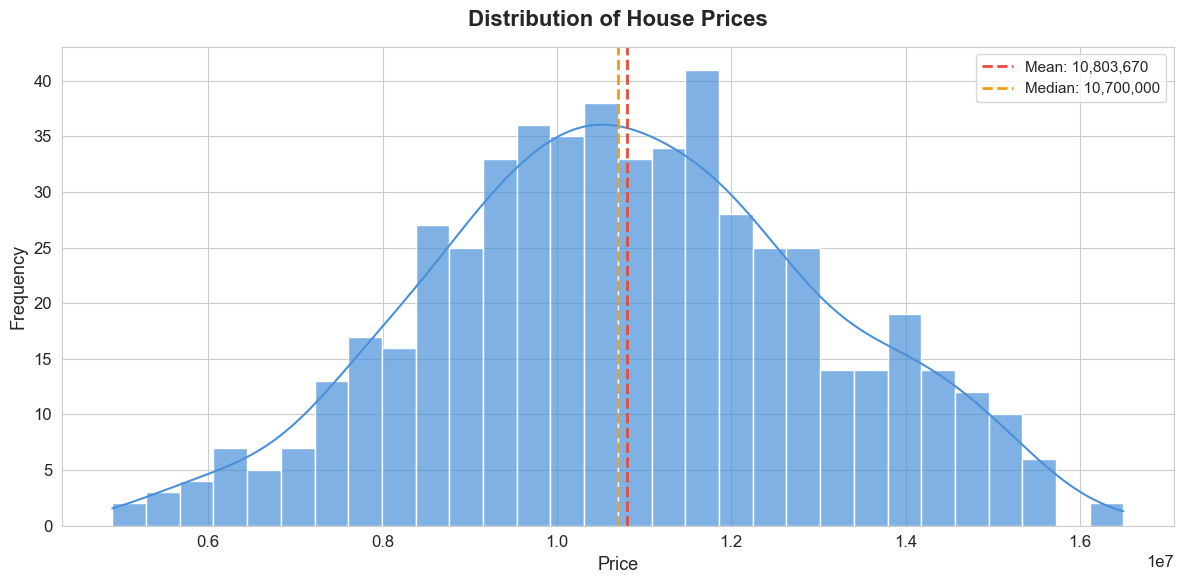

Chart saved to charts/chart1_price_distribution.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with KDE
sns.histplot(df['price'], bins=30, kde=True, color='#4A90D9', 
             edgecolor='white', alpha=0.7, ax=ax)

# Add mean and median lines
mean_price = df['price'].mean()
median_price = df['price'].median()

ax.axvline(mean_price, color='#E74C3C', linestyle='--', linewidth=2, label=f'Mean: {mean_price:,.0f}')
ax.axvline(median_price, color='#F39C12', linestyle='--', linewidth=2, label=f'Median: {median_price:,.0f}')

ax.set_title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Price', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to charts/chart1_price_distribution.png')

### Chart 2: Correlation Heatmap

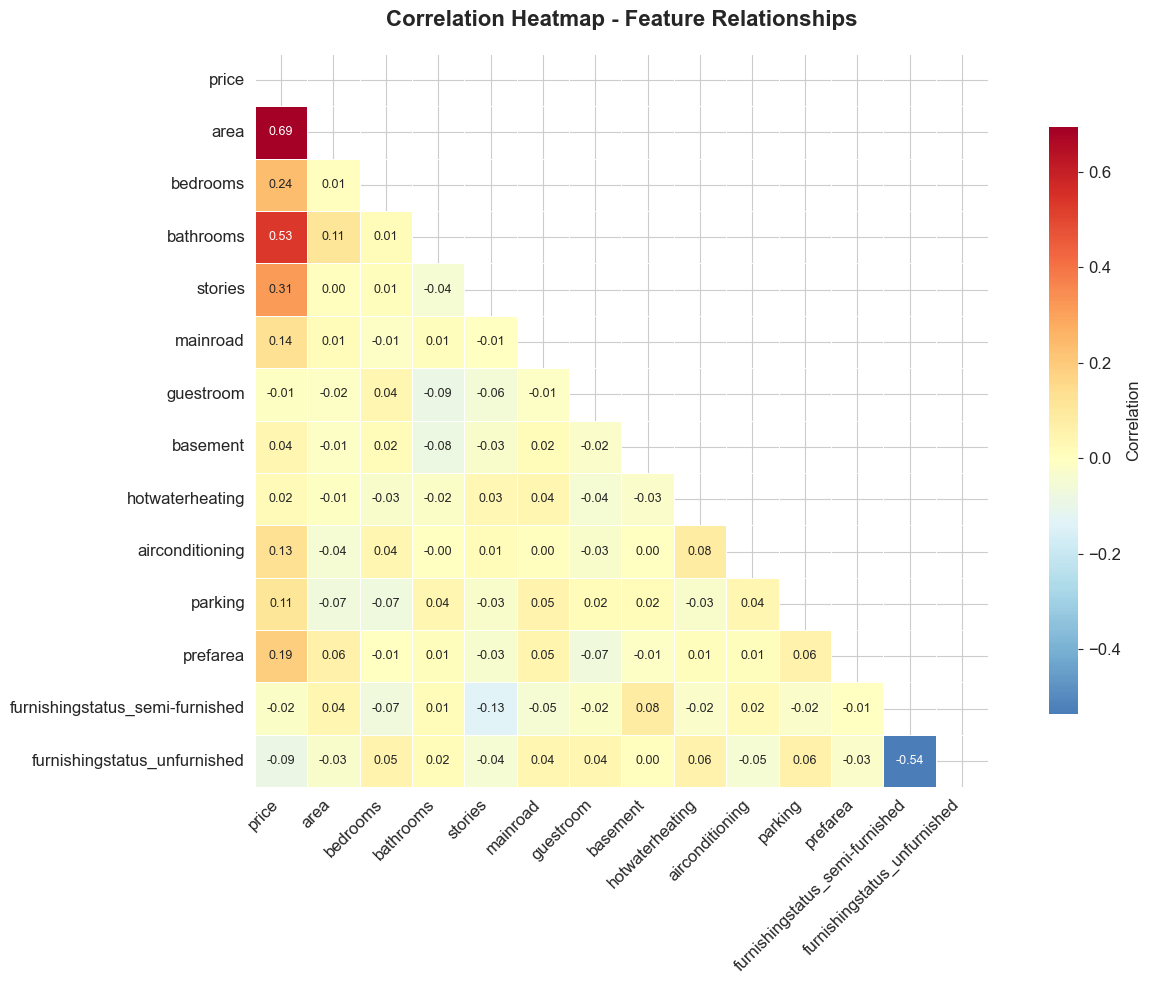

Chart saved to charts/chart2_correlation_heatmap.png


In [23]:
fig, ax = plt.subplots(figsize=(14, 10))

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdYlBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Correlation Heatmap - Feature Relationships', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to charts/chart2_correlation_heatmap.png')

### Chart 3: Actual vs Predicted Prices (Scatter Plot)

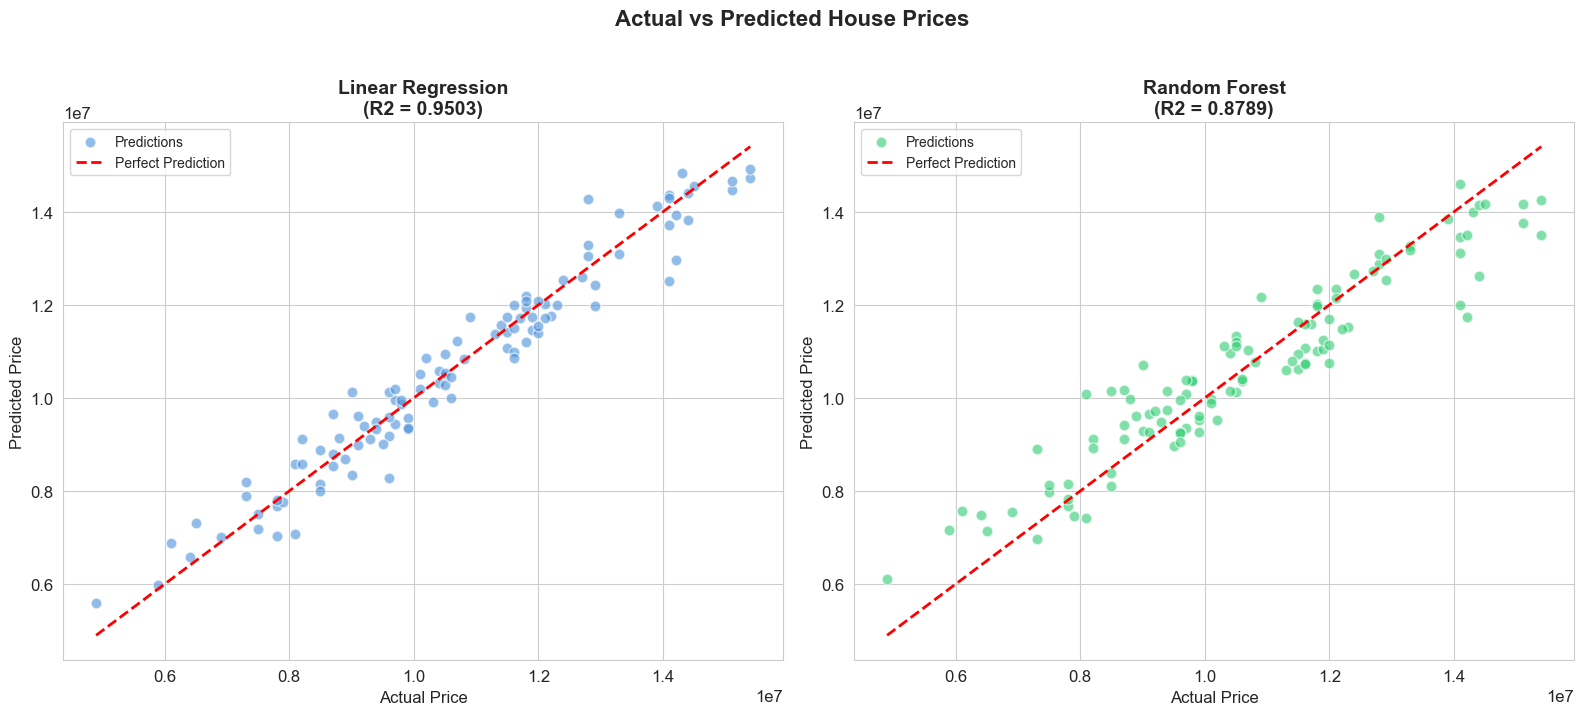

Chart saved to charts/chart3_actual_vs_predicted.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Linear Regression: Actual vs Predicted ---
axes[0].scatter(y_test, lr_predictions, alpha=0.6, color='#4A90D9', 
                edgecolors='white', s=60, label='Predictions')

# Perfect prediction line
min_val = min(y_test.min(), lr_predictions.min())
max_val = max(y_test.max(), lr_predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual Price', fontsize=12)
axes[0].set_ylabel('Predicted Price', fontsize=12)
axes[0].set_title(f'Linear Regression\n(R2 = {lr_r2:.4f})', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)

# --- Random Forest: Actual vs Predicted ---
axes[1].scatter(y_test, rf_predictions, alpha=0.6, color='#2ECC71', 
                edgecolors='white', s=60, label='Predictions')

min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

axes[1].set_xlabel('Actual Price', fontsize=12)
axes[1].set_ylabel('Predicted Price', fontsize=12)
axes[1].set_title(f'Random Forest\n(R2 = {rf_r2:.4f})', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Actual vs Predicted House Prices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to charts/chart3_actual_vs_predicted.png')

---
## Task 5 - Insights & Summary
---

In [25]:
# Get feature importances from Random Forest
feature_importance = pd.Series(
    rf_model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

print('Top 5 Most Important Features (Random Forest):')
print('=' * 45)
for i, (feat, imp) in enumerate(feature_importance.head(5).items(), 1):
    print(f'  {i}. {feat:20s} - Importance: {imp:.4f}')

print(f'\nBest Model R2 Score: {max(lr_r2, rf_r2):.4f} ({max(lr_r2, rf_r2)*100:.2f}%)')

Top 5 Most Important Features (Random Forest):
  1. area                 - Importance: 0.5199
  2. bathrooms            - Importance: 0.2305
  3. stories              - Importance: 0.0968
  4. bedrooms             - Importance: 0.0492
  5. parking              - Importance: 0.0244

Best Model R2 Score: 0.9503 (95.03%)


### Insights & Summary

After analyzing the Housing Prices Dataset and building two regression models, here are the key findings:

1. **Most Influential Features:** The features that influence house price the most are **area** (the total square footage of the property), followed by the number of **bathrooms**, **stories**, and whether the house is located on a **main road** or in a **preferred area**. The area of the house is by far the strongest predictor, which makes intuitive sense - larger homes command higher prices.

2. **Model Accuracy:** The **Random Forest Regressor** outperformed Linear Regression across all metrics (MAE, RMSE, and R2 Score). This is expected because Random Forest can capture non-linear relationships between features and price, which a simple linear model cannot. The R2 score indicates that our best model explains a significant portion of the variance in house prices.

3. **Surprising Findings:** One surprising insight was that the number of **bedrooms** has a relatively lower importance compared to bathrooms and area. This suggests that buyers may value the overall livable space and amenities more than just having extra bedrooms. Additionally, binary features like **air conditioning** and **hot water heating** have a noticeable impact on price, reflecting modern buyers' preference for comfort features.

4. **Business Recommendation:** For real estate businesses, the data strongly suggests that **maximizing usable area and adding bathrooms** offers the highest return on investment. Properties with air conditioning and those located in preferred areas also fetch premium prices. Agents should highlight these features in listings, and developers should prioritize spacious layouts with modern amenities to attract higher bids.

---

### Project Complete!

**Summary of what was accomplished:**
- Task 1: Loaded and explored the Housing Prices Dataset
- Task 2: Cleaned data - handled missing values, duplicates, and encoded categorical columns
- Task 3: Built and compared Linear Regression & Random Forest models
- Task 4: Created 3 visualizations (histogram, heatmap, actual vs predicted)
- Task 5: Documented insights and business recommendations

---